In [20]:
from dataclasses import dataclass
import sys
import json
import argparse
import matplotlib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings as w

@dataclass
class Segment:
    name: str
    start: int 
    end: int 

    matrices : np.ndarray | None = None

    mean : np.ndarray | None = None
    std: np.ndarray | None = None
    median: np.ndarray | None = None
    q25: np.ndarray | None = None
    q75: np.ndarray | None = None
    
    @property
    def n_windows(self):
        if self.matrices is None:
            return 0
        return len(self.matrices)

    @property
    def color(self) -> str:
        return SEG_COLORS[self.name]

    @property 
    def ok(self):
        return self.matrices is not None and len(self.matrices) > 0 

    def load_segment_matrices(self, matrices, metadata):
        #treba prevest sekundy na cislo matrice podle toho jake je meno parametru!
        #step_s = metadata["step_s"]
        step_s = metadata.get("step_s", 1)
        self.matrices = matrices[(self.start//step_s) : (self.end//step_s)]

    def compute_metrics(self):
        if self.matrices is None:
            return
        upper = np.triu_indices(self.matrices.shape[1], k=1)
        self.mean = np.array([np.mean(m[upper]) for m in self.matrices])
        self.std = np.array([np.std(m[upper])  for m in self.matrices])
        self.median = np.array([np.median(m[upper]) for m in self.matrices])
        self.q25 = np.array([np.percentile(m[upper], 25) for m in self.matrices])
        self.q75 = np.array([np.percentile(m[upper], 75) for m in self.matrices])
        
    @property
    def mean_matrix(self):
        return np.mean(self.matrices, axis=0) if self.ok else None
        
    @property
    def mean_windows(self): #np.mean(self.matrices, axis=(1,2)) umele zvedani hodnoty ig
        upper = np.triu_indices(self.matrices.shape[1], k=1)
        values = self.matrices[:,upper[0],upper[1]]
        return np.mean(values, axis = 1)

    def scalar(self, metric):
        #GUMBUS WERRY COOL... NICE
        arr = getattr(self,metric)
        return float(np.mean(arr)) if arr is not None else None

def load_matrices(param_dir):
    """Load all .npy files sorted by filename."""
    files = sorted(param_dir.glob("*.npy"))
    if not files:
        raise FileNotFoundError(f"No .npy files in {param_dir}")

    return np.stack([np.load(f) for f in files])


def load_metadata(param_dir):
    meta_path = param_dir / "metadata.json"

    if meta_path.exists():
        with open(meta_path) as f:
            return json.load(f)

    return {}

param_dir = Path("./Data/C04/sf250_win10_step1_bp1-45/")
matrices = load_matrices(param_dir)
metadata = load_metadata(param_dir)
segments = {

    "FEO": Segment("FEO", 10, 20),

    "LEO": Segment("LEO", 270, 280),

    "FEC": Segment("FEC", 320, 330),

    "LEC": Segment("LEC", 580, 590),

}
for seg in segments.values():
    seg.load_segment_matrices(matrices, metadata)
    print(seg.mean_windows)
    print()
    


[-0.00181125 -0.00169973 -0.00260977 -0.00266314 -0.0023576  -0.00291776
 -0.00261312 -0.00294099 -0.00272882 -0.0016387 ]

[-0.0029952  -0.00282453 -0.0028889  -0.00260002 -0.00215941 -0.00308664
 -0.00281651 -0.0025993  -0.00155645 -0.00084899]

[0.00996402 0.00951651 0.0078438  0.00901857 0.00860669 0.00729434
 0.00830162 0.00943801 0.01032729 0.01016262]

[0.0209724  0.02091244 0.02120385 0.02282166 0.0233172  0.02147507
 0.02127802 0.02113561 0.02143774 0.02102048]



<h2>Heatmaps</h2>
Jak vypadá konektivita během každého segmentu

Cíl první verze: Vstupem je jedna matice a výstup je jedna heatmapa
Mobilita: titulky, colormap, popisky 

Input: segments and metadata
Outup1: 4 different heatmaps, each one for one segments 


FEO (10, 124, 124)
LEO (10, 124, 124)
FEC (10, 124, 124)
LEC (10, 124, 124)


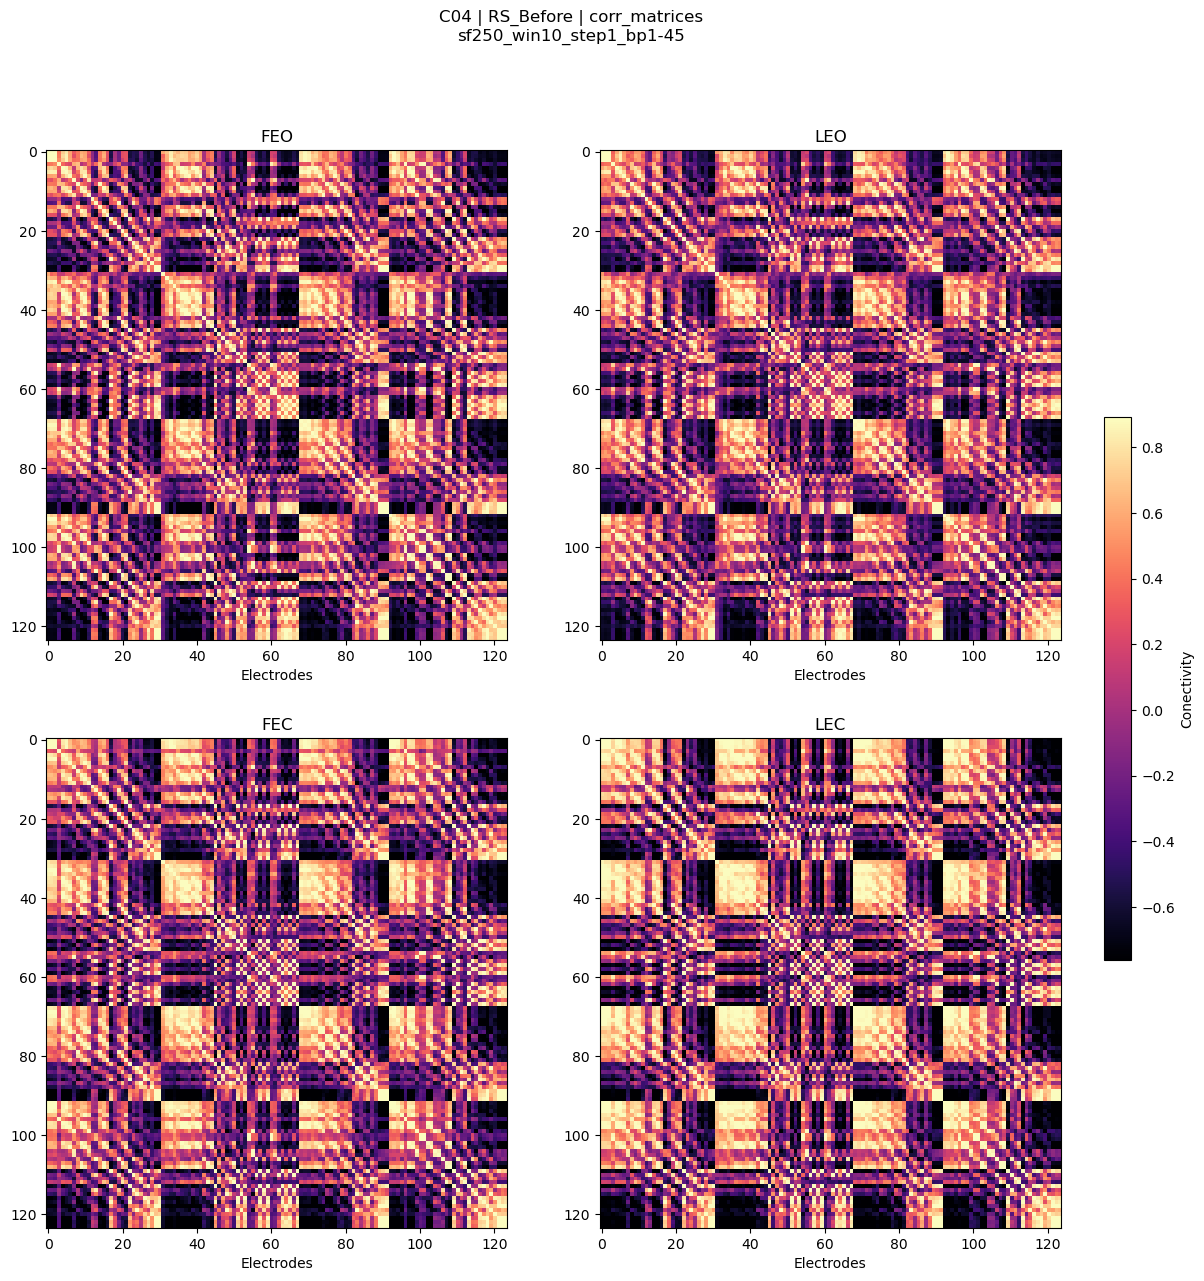

In [4]:
import matplotlib.pyplot as plt

def vminmax(segments, order):
    # collect all matrices
    matrices = [
        segments[label].mean_matrix
        for label in order
    ]

    all_values = np.concatenate(
        [m.flatten() for m in matrices]
    )

    vmin = np.percentile(all_values, 5)
    vmax = np.percentile(all_values, 95)
    return vmin, vmax
    
def plot_matrix_heatmap(segments, metadata, output_dir = None, subject ="C04", recording ="RS_Before", matrix_type = "corr_matrices", params = "sf250_win10_step1_bp1-45"):
    """
    seg_names = ["FEO", "LEO", "FEC", "LEC"]
    STAT_ROWS = ["mean", "std", "median", "Q25", "Q75", "min", "max"]
    """
    fig, axes = plt.subplots(2,2,
                           figsize=(14,14))
    axes = axes.flatten()
    seg_names = ["FEO", "LEO", "FEC", "LEC"]

    vmin, vmax = vminmax(segments, seg_names)
    

    for ax, (label, seg) in zip(axes, segments.items()):
        
        print(label, seg.matrices.shape)
        matrix = seg.mean_matrix
    
        im = ax.imshow(
            matrix,
            cmap="magma",
            vmin=vmin,
            vmax=vmax,
            aspect="auto"
        )
    
        ax.set_title(label)
        ax.set_xlabel("Electrodes")
    fig.colorbar(im, ax = axes, fraction = 0.025, pad = 0.04, label = "Conectivity")
    fig.suptitle(
        f"{subject} | {recording} | {matrix_type}\n{params}"
    )

    return fig, axes

fig = plot_matrix_heatmap(segments, metadata)

plt.show()
    

FEO → LEO: coz
FEC → LEC: coz
LEO -> FEC: coz 
FEO -> LEC: coz

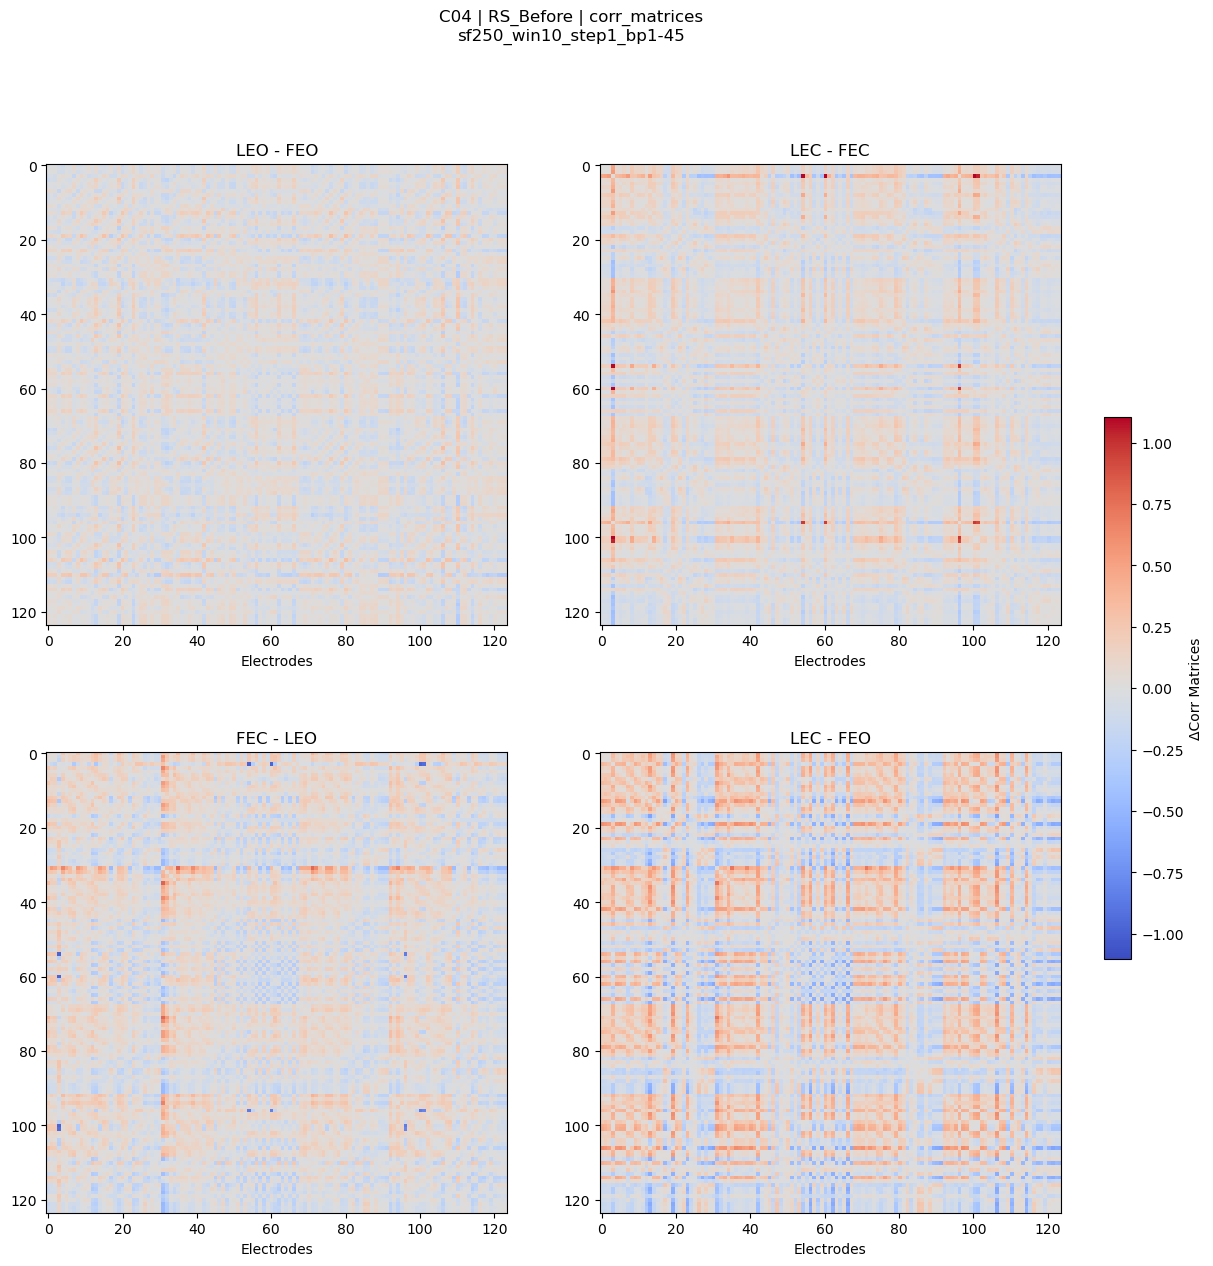

In [6]:
def plot_difference_heatmaps(segments, metadata, output_dir = None, subject ="C04",
                    recording ="RS_Before", matrix_type = "corr_matrices", params = "sf250_win10_step1_bp1-45"):
    comparisons = [("FEO", "LEO"),
                   ("FEC", "LEC"),
                   ("LEO", "FEC"),
                   ("FEO", "LEC")]
    
    differences = []

    for before, after in comparisons:

        diff = (
            segments[after].mean_matrix
            -
            segments[before].mean_matrix
        )

        differences.append(diff)
        
    #plot -----------------------------------
    fig, axes = plt.subplots(2,2,
                           figsize=(14,14))
    axes = axes.flatten()
    
    max_abs = np.max([
        np.abs(d).max()
        for d in differences
    ])
    for ax, diff, pair in zip(axes, differences, comparisons):
        im = ax.imshow(diff, cmap = "coolwarm", vmax=max_abs, vmin=-max_abs)
        ax.set_title(
            f"{pair[1]} - {pair[0]}"
        )

        ax.set_xlabel("Electrodes")
    
    fig.colorbar(
        im,
        ax=axes,
        label="ΔCorr Matrices",
        fraction = 0.025, pad = 0.04
    )
    fig.suptitle(
        f"{subject} | {recording} | {matrix_type}\n{params}"
    )

    return fig, axes


fig = plot_difference_heatmaps(
    segments,
    metadata
)

plt.show()

<h2>Heatmaps diff</h2>

In [8]:
def print_biggest_electrode_changes(
        segments,
        comparisons=None,
        top_n=10 ):
    if comparisons is None:
        comparisons = [
            ("FEO", "LEO"),
            ("FEC", "LEC"),
            ("LEO", "FEC"),
            ("FEO", "LEC")
        ]


    for before, after in comparisons:

        print("\n" + "="*50)
        print(f"{after} - {before}")
        print("="*50)


        diff = (
            segments[after].mean_matrix
            -
            segments[before].mean_matrix
        )


        # electrode importance score
        # average absolute change across all connections
        scores = np.mean(
            np.abs(diff),
            axis=0
        )


        top_idx = np.argsort(scores)[::-1][:top_n]


        for rank, idx in enumerate(top_idx, start=1):

            print(
                f"{rank:2d}. Electrode {idx:2d} "
                f"| change = {scores[idx]:.5f}"
            )

print_biggest_electrode_changes(segments)


LEO - FEO
 1. Electrode 110 | change = 0.17062
 2. Electrode 106 | change = 0.14517
 3. Electrode 19 | change = 0.13839
 4. Electrode 13 | change = 0.11749
 5. Electrode 23 | change = 0.11643
 6. Electrode 56 | change = 0.11306
 7. Electrode 32 | change = 0.11242
 8. Electrode 66 | change = 0.11228
 9. Electrode 114 | change = 0.10823
10. Electrode 62 | change = 0.10581

LEC - FEC
 1. Electrode  3 | change = 0.34117
 2. Electrode 96 | change = 0.26960
 3. Electrode 100 | change = 0.19890
 4. Electrode 54 | change = 0.19750
 5. Electrode 101 | change = 0.19235
 6. Electrode 60 | change = 0.18302
 7. Electrode 42 | change = 0.14914
 8. Electrode 79 | change = 0.14045
 9. Electrode 106 | change = 0.13938
10. Electrode 19 | change = 0.13914

FEC - LEO
 1. Electrode 31 | change = 0.31663
 2. Electrode 32 | change = 0.21649
 3. Electrode 92 | change = 0.17107
 4. Electrode 94 | change = 0.16872
 5. Electrode  3 | change = 0.15820
 6. Electrode 12 | change = 0.15320
 7. Electrode 34 | change

In [10]:
def collect_condition_differences(segments):

    feo_leo = []
    fec_lec = []


    #for segment in segments.items():

    diff_open = (
        segments["LEO"].mean_matrix
        -
        segments["FEO"].mean_matrix
    )

    diff_closed = (
        segments["LEC"].mean_matrix
        -
        segments["FEC"].mean_matrix
    )


    feo_leo.append(diff_open)
    fec_lec.append(diff_closed)


    return (
        np.stack(feo_leo),
        np.stack(fec_lec)
    )

def summarize_group_difference(diff_stack):

    mean_diff = np.mean(
        diff_stack,
        axis=0
    )

    consistency = np.mean(
        np.sign(diff_stack) == np.sign(mean_diff),
        axis=0
    )

    return mean_diff, consistency

def rank_group_electrodes(mean_diff, consistency):

    magnitude = np.mean(
        np.abs(mean_diff),
        axis=0
    )

    ranking = np.argsort(
        magnitude
    )[::-1]


    for idx in ranking[:10]:

        print(
            f"Electrode {idx}: "
            f"magnitude={magnitude[idx]:.4f}, "
            f"consistency={np.mean(consistency[idx]):.2f}"
        )
        
one, two = collect_condition_differences(segments)
mean_diff, consistency = summarize_group_difference(one)
rank_group_electrodes(mean_diff, consistency)

Electrode 110: magnitude=0.1706, consistency=1.00
Electrode 106: magnitude=0.1452, consistency=1.00
Electrode 19: magnitude=0.1384, consistency=1.00
Electrode 13: magnitude=0.1175, consistency=1.00
Electrode 23: magnitude=0.1164, consistency=1.00
Electrode 56: magnitude=0.1131, consistency=1.00
Electrode 32: magnitude=0.1124, consistency=1.00
Electrode 66: magnitude=0.1123, consistency=1.00
Electrode 114: magnitude=0.1082, consistency=1.00
Electrode 62: magnitude=0.1058, consistency=1.00


<h2>Distribution</h2>

Výsledkem je histogram o asi 7,2k hodnot které odpovídají na otázku jaká je distribude konektivity v matici
Víme pak jestli spojení zesílilo, zeskáblo, je heterogenní apod
Nikoliv ale histogram jedné mean matice ale všech 10 matic v segmentu 

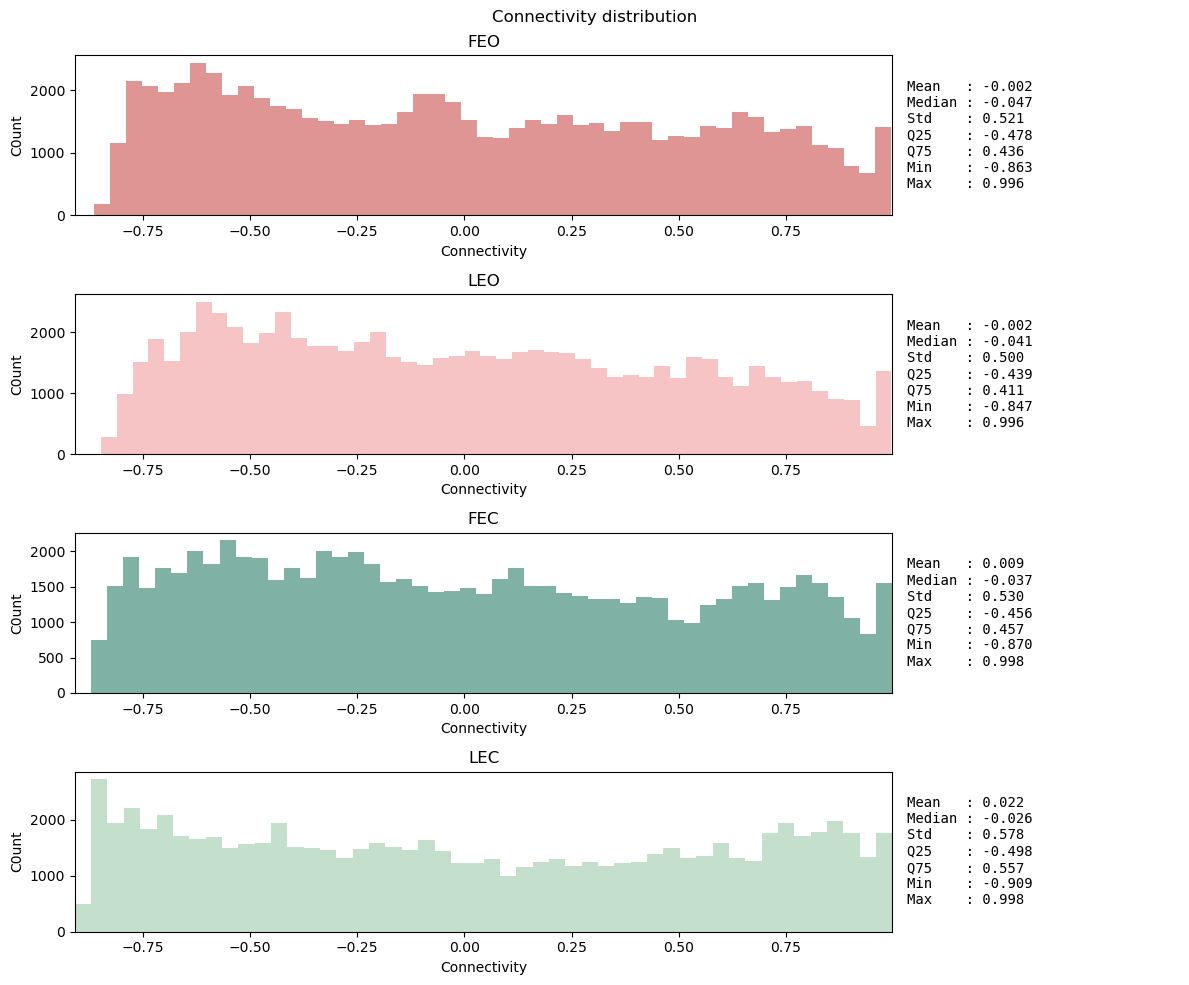

In [11]:
SEG_COLORS = {
    "FEO": "indianred",
    "LEO": "lightcoral",

    "FEC": "darkseagreen",
    "LEC": "lightseagreen"
}
SEG_COLORS2 = {
    "FEO": "#D97B7B",
    "LEO": "#F4B6B6",

    "FEC": "#5F9F8F",
    "LEC": "#B7D7C1"
}
SEG_COLORS3 = {
    "FEO": "#E9967A",   # pastel red/orange
    "LEO": "#FFC1B6",

    "FEC": "#66A182",
    "LEC": "#B5D8C5"
}
def all_values_distribution(segments):
    all_values = []

    for seg in segments.values():
        upper = np.triu_indices(seg.matrices.shape[1], k=1)
        all_values.append(seg.matrices[:, upper[0], upper[1]].flatten())
    
    all_values = np.concatenate(all_values)
    
    xmin = np.min(all_values)
    xmax = np.max(all_values)
    
    return xmin, xmax
    
def plot_connectivity_distribution(segments): # jak caste
    fig, axes = plt.subplots(4,2, 
                         figsize= (12,10),
                            gridspec_kw={"width_ratios":[3,1]})
    seg_names = ["FEO", "LEO", "FEC", "LEC"]
    STAT_ROWS = ["mean", "std", "median", "Q25", "Q75", "min", "max"]
    
    vmin, vmax = all_values_distribution(segments)
    
    for row, label in enumerate(seg_names):
        seg = segments[label]
        upper = np.triu_indices(seg.matrices.shape[1], k = 1)#just indexes of upper, no diagonal values in 2D
        matrix_values = seg.matrices[:, upper[0], upper[1]] # all time vindows:, na tom 2D poly index
        matrix_values = matrix_values.flatten()


        #----Histogram 
        ax = axes[row, 0]

        ax.hist(
            matrix_values, 
            bins=50,
            color=SEG_COLORS2[label],
            alpha= 0.8)
        
        ax.set_xlim(vmin, vmax)
        ax.set_title(label)
        ax.set_xlabel("Connectivity")
        ax.set_ylabel("C0unt")


        #----Statistics 
        stats = axes[row, 1]
        stats.axis("off")

        text = (
            f"Mean   : {np.mean(matrix_values):.3f}\n"
            f"Median : {np.median(matrix_values):.3f}\n"
            f"Std    : {np.std(matrix_values):.3f}\n"
            f"Q25    : {np.percentile(matrix_values,25):.3f}\n"
            f"Q75    : {np.percentile(matrix_values,75):.3f}\n"
            f"Min    : {np.min(matrix_values):.3f}\n"
            f"Max    : {np.max(matrix_values):.3f}"
        )

        stats.text(
            0,
            0.5,
            text,
            fontsize=10,
            va="center",
            family="monospace"
        )
    fig.suptitle("Connectivity distribution")
    plt.tight_layout()
    return fig, axes

fig, axes = plot_connectivity_distribution(segments)
plt.show()

Ale u histogramu:

np.mean(self.matrices, axis=(1,2))

by ses ptala:

"Jaká je průměrná hodnota všech spojení v síti?"

A tam se diagonála dostane přímo do čísla.

Například malá síť:

3 elektrody

matice:

1   0.5 0.5
0.5 1   0.5
0.5 0.5 1

Bez diagonály:

(0.5+0.5+0.5)/3 = 0.5

S diagonálou:

(1+1+1+0.5+0.5+0.5)/9

= 0.83

Najednou jsi "objevila" extrémně synchronizovaný mozek. Ve skutečnosti jsi jen započítala fakt, že elektroda sama se sebou má korelaci 1. Mozek mezitím ani nedostal šanci něco udělat. 😄

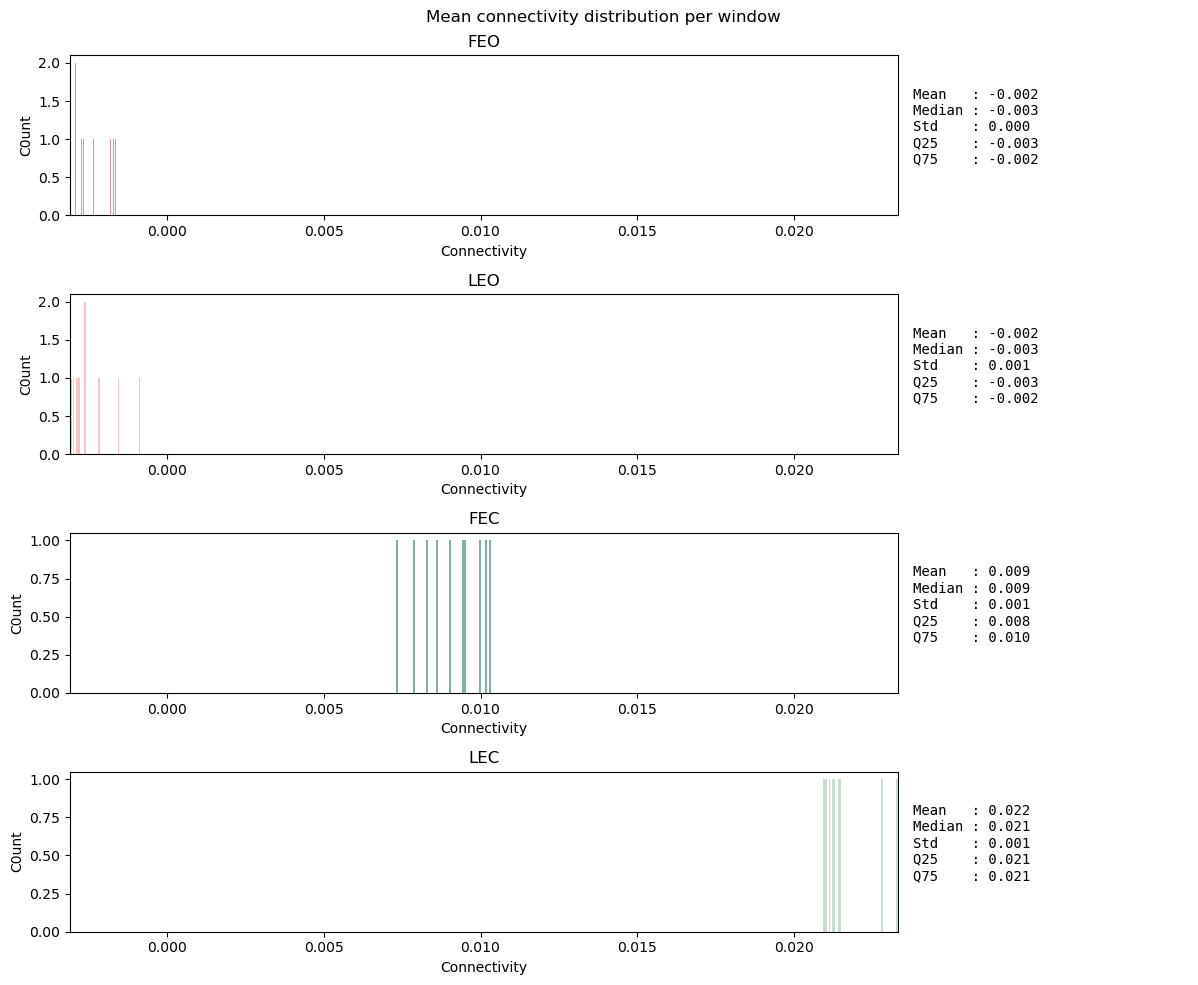

In [32]:
def mean_connectivity_distribution(segments):
    fig, axes = plt.subplots(4,2, figsize=(12,10), gridspec_kw={"width_ratios":[3,1]})
    #axes = axes.flatten()
    seg_names = ["FEO", "LEO", "FEC", "LEC"]

    
    def vminmaxim (segments, seg_names):
        arr = []
        for seg in seg_names:
            arr.extend(segments[seg].mean_windows)
        xmin = np.min(arr)
        xmax = np.max(arr)
        
        return xmin, xmax
        
    vmin, vmax = vminmaxim(segments, seg_names)    
    
    for row, labels in enumerate(seg_names):
        seg = segments[labels]
        matrices = seg.mean_windows
        #dist
        ax = axes[row, 0]

        ax.hist(
            matrices, 
            bins=50,
            color=SEG_COLORS2[labels],
            alpha= 0.8)
        
        ax.set_xlim(vmin, vmax)
        ax.set_title(labels)
        ax.set_xlabel("Connectivity")
        ax.set_ylabel("C0unt")
        #stats 
        stats = axes[row, 1]
        stats.axis("off")
        
        text = (
            f"Mean   : {np.mean(matrices):.3f}\n"
            f"Median : {np.median(matrices):.3f}\n"
            f"Std    : {np.std(matrices):.3f}\n"
            f"Q25    : {np.percentile(matrices,25):.3f}\n"
            f"Q75    : {np.percentile(matrices,75):.3f}\n"
        )
        stats.text(
            0,
            0.5,
            text,
            fontsize=10,
            va="center",
            family="monospace"
        )
        
        


    fig.suptitle(
        "Mean connectivity distribution per window"
    )
    
    plt.tight_layout()
    return fig, axes

fig, axes = mean_connectivity_distribution(segments)
plt.show()

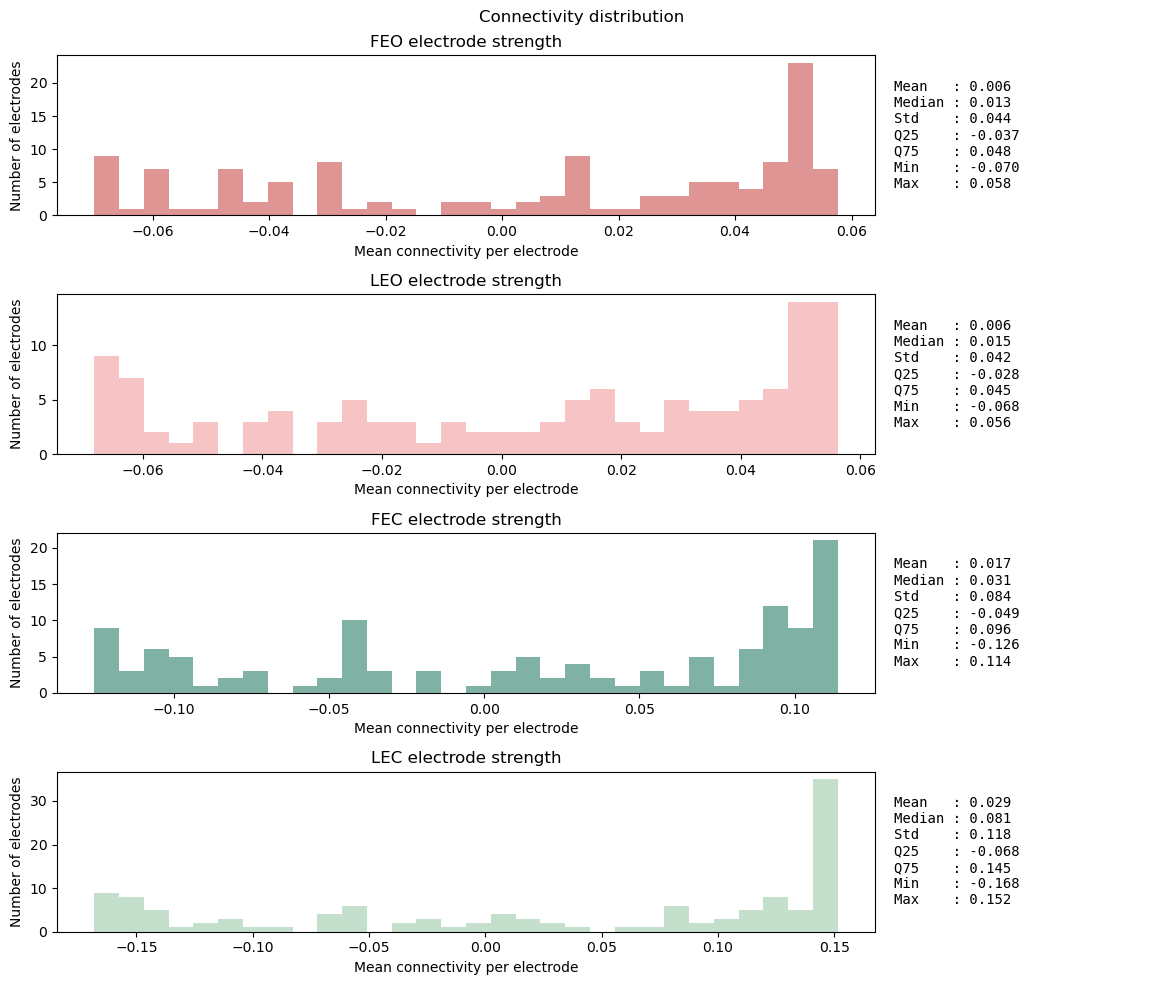

In [39]:
def node_strength_connectivity_distribution(segments): # jak caste
    fig, axes = plt.subplots(4,2, 
                         figsize= (12,10),
                            gridspec_kw={"width_ratios":[3,1]})

    seg_names = ["FEO", "LEO", "FEC", "LEC"]

    
    for row, label in enumerate(seg_names):
        seg = segments[label]
        node_strength = np.mean(
            seg.mean_matrix,
            axis=1
        )


        #----Histogram 
        ax = axes[row, 0]

        ax.hist(
            node_strength, 
            bins=30,
            color=SEG_COLORS2[label],
            alpha= 0.8)
        
        ax.set_title(
            f"{label} electrode strength"
        )

        ax.set_xlabel(
            "Mean connectivity per electrode"
        )

        ax.set_ylabel(
            "Number of electrodes"
        )

        #----Statistics 
        stats = axes[row, 1]
        stats.axis("off")

        text = (
            f"Mean   : {np.mean(node_strength):.3f}\n"
            f"Median : {np.median(node_strength):.3f}\n"
            f"Std    : {np.std(node_strength):.3f}\n"
            f"Q25    : {np.percentile(node_strength,25):.3f}\n"
            f"Q75    : {np.percentile(node_strength,75):.3f}\n"
            f"Min    : {np.min(node_strength):.3f}\n"
            f"Max    : {np.max(node_strength):.3f}"
        )

        stats.text(
            0,
            0.5,
            text,
            fontsize=10,
            va="center",
            family="monospace"
        )
    fig.suptitle("Connectivity distribution")
    plt.tight_layout()
    return fig, axes

fig, axes = node_strength_connectivity_distribution(segments)
plt.show()

Rozdíl mezi našimi třemi distribucemi:

Funkce	Co je jedna hodnota?	Otázka

plot_connectivity_distribution	jedno spojení (electrode-electrode)	Jaké PLV hodnoty se vyskytují?

mean_connectivity_distribution	jedno časové okno	Je stav stabilní v čase?

electrode_strength_distribution	jedna elektroda	Které elektrody jsou huby?

Takže tvoje intuice byla správná, že to "vypadá podobně", protože všude děláme nějaký průměr. Rozdíl je, jestli průměruješ přes čas, přes spoje, nebo přes elektrody. A přesně tady začíná ta část analýzy, kde už z obyčejné matice vytahujeme vlastnosti sítě.